## Per-side velocity model for every Paleo Lithia shot

For every shot in `all_picks_80-20hz_firsthits.sgt`, the t–x curve on each side of the shot is fit **independently** — no mirroring. The number of layers per side (1, 2, or 3) is chosen automatically by BIC, so a side without a clear slope break gets a 1-layer fit. Apparent velocities must increase with offset for a multi-layer fit to be accepted.

- **Left side** = geophones at offsets < shot position (red)
- **Right side** = geophones at offsets > shot position (blue)
- Solid line = layer 1, dashed = layer 2, dotted = layer 3
- Depths come from the standard flat-layer intercept-time formulas.


In [1]:
import numpy as np

# ---- parse a Refrapick .sgt file ----
def read_sgt(path):
    with open(path, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    n_pts = int(lines[0].split()[0])
    i = 1
    if lines[i].startswith("#"):
        i += 1
    sensors = np.array([list(map(float, lines[i + k].split()))
                        for k in range(n_pts)])
    i += n_pts
    n_meas = int(lines[i].split()[0]); i += 1
    if lines[i].startswith("#"):
        i += 1
    meas = np.array([list(map(float, lines[i + k].split()))
                     for k in range(n_meas)])
    return sensors, meas

# ---- helpers: per-side piecewise refraction fit ----
def _line_fit(x, t):
    s, i = np.polyfit(x, t, 1)
    sse = float(np.sum((s*x + i - t)**2))
    return s, i, sse

def fit_piecewise(x, t, kmax=3, min_per_seg=3):
    """Fit a piecewise-linear t-x model with k = 1..kmax segments.

    Constraints
    -----------
    - each segment has >= min_per_seg points
    - slopes strictly decrease (so apparent velocities increase with offset)

    Selection
    ---------
    k is chosen by BIC = n*log(SSE/n) + (3k - 1)*log(n).
    """
    n = len(x)
    candidates = []

    if n >= min_per_seg:
        s1, i1, sse = _line_fit(x, t)
        candidates.append({"k":1, "breaks":[], "slopes":[s1],
                           "intercepts":[i1], "sse":sse})

    if n >= 2*min_per_seg and kmax >= 2:
        best = None
        for b in range(min_per_seg, n - min_per_seg + 1):
            s1, i1, e1 = _line_fit(x[:b], t[:b])
            s2, i2, e2 = _line_fit(x[b:], t[b:])
            if s2 >= s1:
                continue
            sse = e1 + e2
            if best is None or sse < best["sse"]:
                best = {"k":2, "breaks":[b], "slopes":[s1,s2],
                        "intercepts":[i1,i2], "sse":sse}
        if best is not None:
            candidates.append(best)

    if n >= 3*min_per_seg and kmax >= 3:
        best = None
        for b1 in range(min_per_seg, n - 2*min_per_seg + 1):
            for b2 in range(b1 + min_per_seg, n - min_per_seg + 1):
                s1, i1, e1 = _line_fit(x[:b1], t[:b1])
                s2, i2, e2 = _line_fit(x[b1:b2], t[b1:b2])
                s3, i3, e3 = _line_fit(x[b2:], t[b2:])
                if not (s1 > s2 > s3):
                    continue
                sse = e1 + e2 + e3
                if best is None or sse < best["sse"]:
                    best = {"k":3, "breaks":[b1,b2], "slopes":[s1,s2,s3],
                            "intercepts":[i1,i2,i3], "sse":sse}
        if best is not None:
            candidates.append(best)

    if not candidates:
        return None

    for c in candidates:
        p = 3*c["k"] - 1
        c["bic"] = n * np.log(max(c["sse"], 1e-20) / n) + p * np.log(n)
    return min(candidates, key=lambda c: c["bic"])


def depths_from_fit(fit):
    """Cumulative depths to each refractor (m) from intercept times (flat layers)."""
    v  = [1.0/s for s in fit["slopes"]]
    ti = fit["intercepts"]
    depths = []
    if len(v) >= 2:
        V1, V2 = v[0], v[1]
        h1 = ti[1] * V1*V2 / (2.0 * np.sqrt(V2**2 - V1**2))
        depths.append(h1)
        if len(v) >= 3:
            V3 = v[2]
            term = ti[2] - 2*h1*np.sqrt(1.0/V1**2 - 1.0/V3**2)
            h2 = term * V2*V3 / (2.0 * np.sqrt(V3**2 - V2**2))
            depths.append(h1 + h2)
    return v, depths


9 shots: [1, 7, 13, 19, 25, 31, 37, 43, 49]


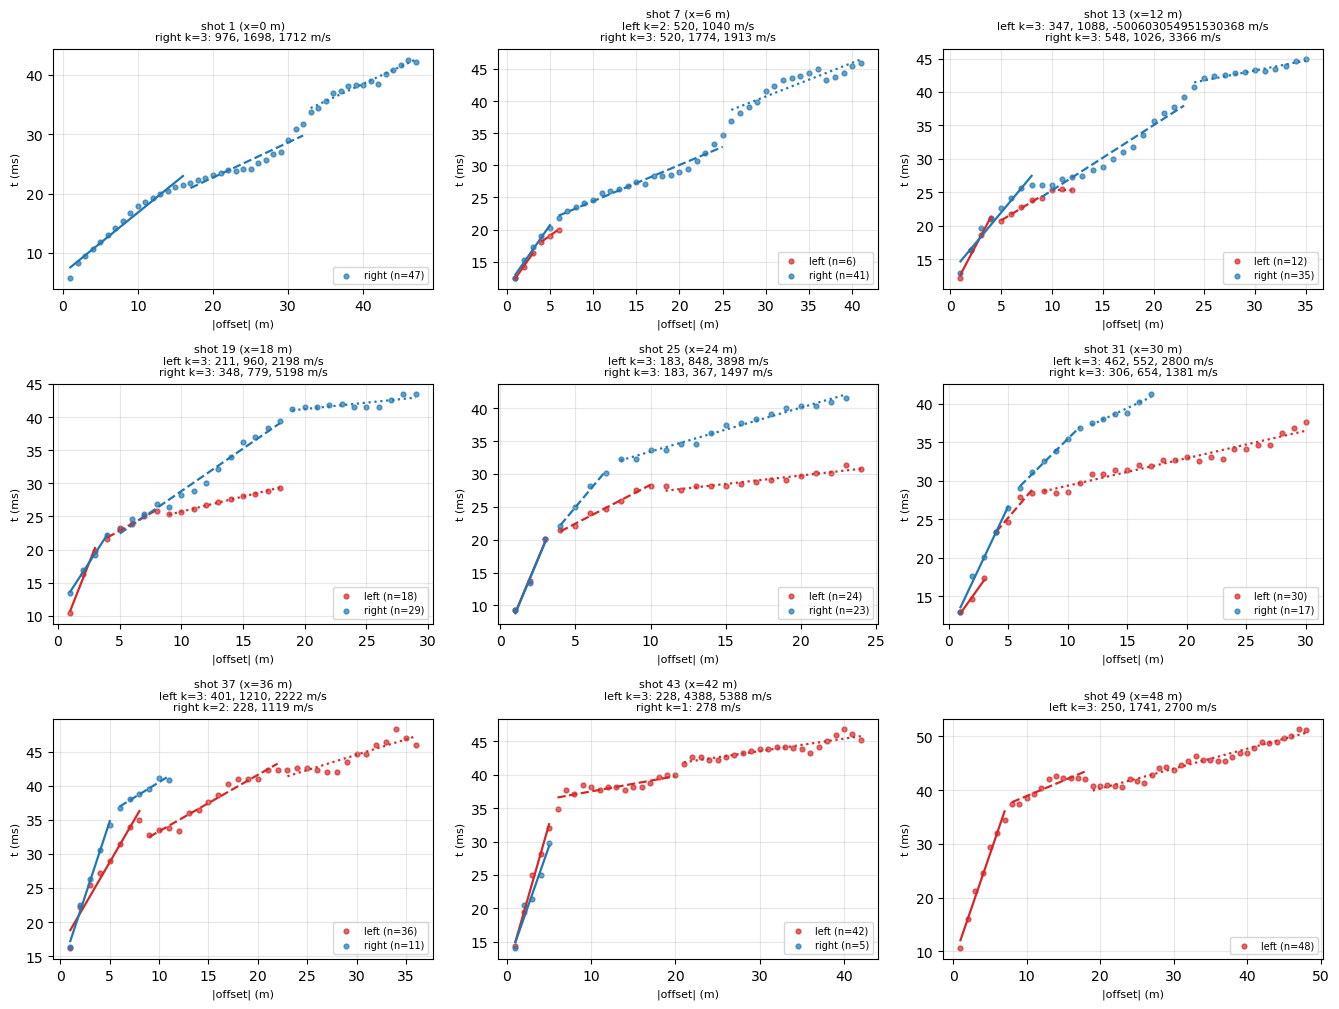

In [2]:
# load combined picks, fit each side of each shot independently, plot grid
import math
import matplotlib.pyplot as plt

picks_path_all = r"../Refrapy/lithia_first_picks/picks/all_picks_80-20hz_firsthits.sgt"
sensors_all, meas_all = read_sgt(picks_path_all)
shot_indices = np.unique(meas_all[:, 0].astype(int))
print(f"{len(shot_indices)} shots: {shot_indices.tolist()}")

# per-shot, per-side fits
results = {}
for s in shot_indices:
    sel  = meas_all[:, 0].astype(int) == s
    g    = meas_all[sel, 1].astype(int)
    tobs = meas_all[sel, 2]
    x_shot = sensors_all[s - 1, 0]
    x_off  = sensors_all[g - 1, 0] - x_shot

    info = {"x_shot": float(x_shot)}
    for name, mask in [("left", x_off < 0), ("right", x_off > 0)]:
        if mask.sum() < 2:
            info[name] = None
            continue
        d  = np.abs(x_off[mask])
        tt = tobs[mask]
        order = np.argsort(d)
        info[name] = {"d": d[order], "t": tt[order],
                      "fit": fit_piecewise(d[order], tt[order])}
    results[int(s)] = info

# plot grid: one panel per shot, both sides overlaid (left = red, right = blue)
n_shots = len(shot_indices)
ncols   = 3
nrows   = math.ceil(n_shots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.4*nrows),
                         sharex=False, sharey=False)
axes = axes.flatten()

linestyles = ['-', '--', ':']
for idx, s in enumerate(shot_indices):
    ax    = axes[idx]
    info  = results[int(s)]
    x_shot = info["x_shot"]
    title_parts = [f"shot {s} (x={x_shot:.0f} m)"]

    for name, color in [("left", "tab:red"), ("right", "tab:blue")]:
        side = info[name]
        if side is None:
            continue
        d, tt = side["d"], side["t"]
        fit   = side["fit"]
        ax.scatter(d, tt*1000, color=color, s=12, alpha=0.7,
                   label=f"{name} (n={len(d)})")
        if fit is None:
            continue
        starts = [0] + fit["breaks"]
        ends   = fit["breaks"] + [len(d)]
        v_app  = [1.0/sl for sl in fit["slopes"]]
        for k in range(fit["k"]):
            xs = np.array([d[starts[k]], d[ends[k]-1]])
            ys = (fit["slopes"][k]*xs + fit["intercepts"][k]) * 1000
            ax.plot(xs, ys, color=color, lw=1.6, linestyle=linestyles[k])
        title_parts.append(
            f"{name} k={fit['k']}: " + ", ".join(f"{vi:.0f}" for vi in v_app) + " m/s"
        )

    ax.set_title("\n".join(title_parts), fontsize=8)
    ax.set_xlabel("|offset| (m)", fontsize=8)
    ax.set_ylabel("t (ms)", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

for j in range(n_shots, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [3]:
# tabular summary of all per-side fits
print(f"{'Shot':>4} {'x_shot':>7} {'Side':>6} {'k':>2}  {'Velocities (m/s)':<24}  Depths (m)")
print("-" * 74)
for s in shot_indices:
    info = results[int(s)]
    x_shot = info['x_shot']
    for name in ('left', 'right'):
        side = info[name]
        if side is None:
            print(f"{s:>4} {x_shot:>7.1f} {name:>6}   - (no picks on this side)")
            continue
        fit = side['fit']
        if fit is None:
            print(f"{s:>4} {x_shot:>7.1f} {name:>6}   - (could not fit)")
            continue
        v, dpths = depths_from_fit(fit)
        v_str = ", ".join(f"{vi:.0f}" for vi in v)
        d_str = ", ".join(f"{di:.1f}" for di in dpths) if dpths else "-"
        print(f"{s:>4} {x_shot:>7.1f} {name:>6} {fit['k']:>2}  {v_str:<24}  {d_str}")


Shot  x_shot   Side  k  Velocities (m/s)          Depths (m)
--------------------------------------------------------------------------
   1     0.0   left   - (no picks on this side)
   1     0.0  right  3  976, 1698, 1712           6.5, 33.8
   7     6.0   left  2  520, 1040                 4.3
   7     6.0  right  3  520, 1774, 1913           5.1, 19.6
  13    12.0   left  3  347, 1088, -500603054951530368  3.0, -1.5
  13    12.0  right  3  548, 1026, 3366           5.0, 13.7
  19    18.0   left  3  211, 960, 2198            1.9, 3.6
  19    18.0  right  3  348, 779, 5198            3.1, 10.8
  25    24.0   left  3  183, 848, 3898            1.6, 4.9
  25    24.0  right  3  183, 367, 1497            1.2, 3.8
  31    30.0   left  3  462, 552, 2800            6.8, 5.9
  31    30.0  right  3  306, 654, 1381            3.5, 5.8
  37    36.0   left  3  401, 1210, 2222           5.3, 8.9
  37    36.0  right  2  228, 1119                 3.7
  43    42.0   left  3  228, 4388, 5388         